In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Load preprocessed custom dataset
df = pd.read_csv('1_delta_replaced_data.csv')


In [2]:
df.head(-1)

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T18:00:00,842.0,534639.0,114176.0,14852.0,648716.0,95435.0,15470.0,657359.0,16248.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,benign
1,2025-07-22T18:00:10,830.0,530504.0,113038.0,14845.0,643445.0,94416.0,14958.0,649089.0,15080.0,...,2.0,2.0,12.0,0.0,0.0,0.0,2.0,12.0,benign,benign
2,2025-07-22T18:00:20,775.0,530791.0,113318.0,15235.0,644009.0,94677.0,16126.0,678009.0,14637.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,benign,benign
3,2025-07-22T18:00:30,895.0,533606.0,113935.0,14633.0,647442.0,95136.0,15474.0,646697.0,14399.0,...,0.0,0.0,-2.0,0.0,0.0,0.0,-1.0,-2.0,benign,benign
4,2025-07-22T18:00:40,822.0,536215.0,114003.0,15363.0,650120.0,95225.0,14512.0,640024.0,14608.0,...,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6684,2025-07-23T12:34:00,802.0,538076.0,114510.0,15062.0,652486.0,95618.0,14769.0,640186.0,15394.0,...,-1.0,-1.0,3.0,0.0,0.0,0.0,1.0,3.0,benign,benign
6685,2025-07-23T12:34:10,854.0,541724.0,115780.0,16307.0,657404.0,96743.0,14578.0,647322.0,15075.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,benign,benign
6686,2025-07-23T12:34:20,767.0,538453.0,115911.0,14974.0,654263.0,96805.0,15306.0,650989.0,15422.0,...,3.0,3.0,1.0,0.0,0.0,0.0,3.0,1.0,benign,benign
6687,2025-07-23T12:34:30,823.0,541888.0,115855.0,15573.0,657644.0,96817.0,14918.0,648631.0,14909.0,...,-1.0,-1.0,-5.0,0.0,0.0,0.0,-3.0,-5.0,benign,benign


In [3]:

# Convert categorical labels to binary format: benign = 0, attack = 1
df['Label'] = df['Label'].replace({'benign': 0, 'attack': 1})

# Define features (X) and target variable (y)
# Drop metadata and redundant columns
X = df.drop(columns=['Label', 'timestamp', 'attack'])
y = df['Label']

# Initialize and train a Decision Tree classifier for feature selection
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

# Optional: show top 20 most important features
importances = pd.Series(clf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(21)

print("Top 20 features based on importance:")
print(top_features)


/tmp/ipykernel_3767051/2319109433.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Label'] = df['Label'].replace({'benign': 0, 'attack': 1})


Top 20 features based on importance:
node-stores                       0.350302
bus_access                        0.153836
skb_kfree_skb                     0.056916
cpu_cycles                        0.021345
tcp_tcp_probe                     0.021276
l2d_cache_wb_victim               0.018308
syscalls_sys_enter_fcntl          0.014023
syscalls_sys_exit_fcntl           0.011195
writeback_global_dirty_state      0.010815
sched_sched_stat_runtime          0.009347
st_spec                           0.008685
syscalls_sys_enter_kill           0.008306
fib_fib_table_lookup              0.008035
kmem_mm_page_alloc_zone_locked    0.007794
sock_inet_sock_set_state          0.007661
l2d_cache_wb                      0.007550
unaligned_st_spec                 0.007045
mem_access_rd                     0.006675
l2d_cache_refill_wr               0.006485
mmc_mmc_request_start             0.006277
br_mis_pred                       0.006234
dtype: float64


Confusion matrix:
[[ 934    0]
 [   0 5756]]


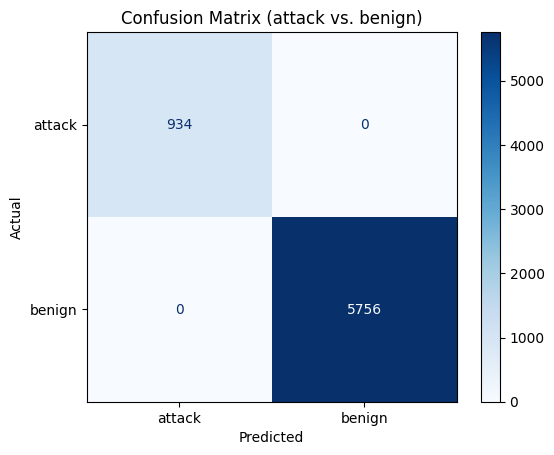

In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Generate predictions on the same dataset (for internal validation only)
y_pred = clf.predict(X)

# Order: attack (1) first, then benign (0)
labels = [1, 0]

# Compute confusion matrix with explicit label order
cm = confusion_matrix(y, y_pred, labels=labels)
print("Confusion matrix:")
print(cm)

# Display with appropriate labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['attack', 'benign'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (attack vs. benign)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


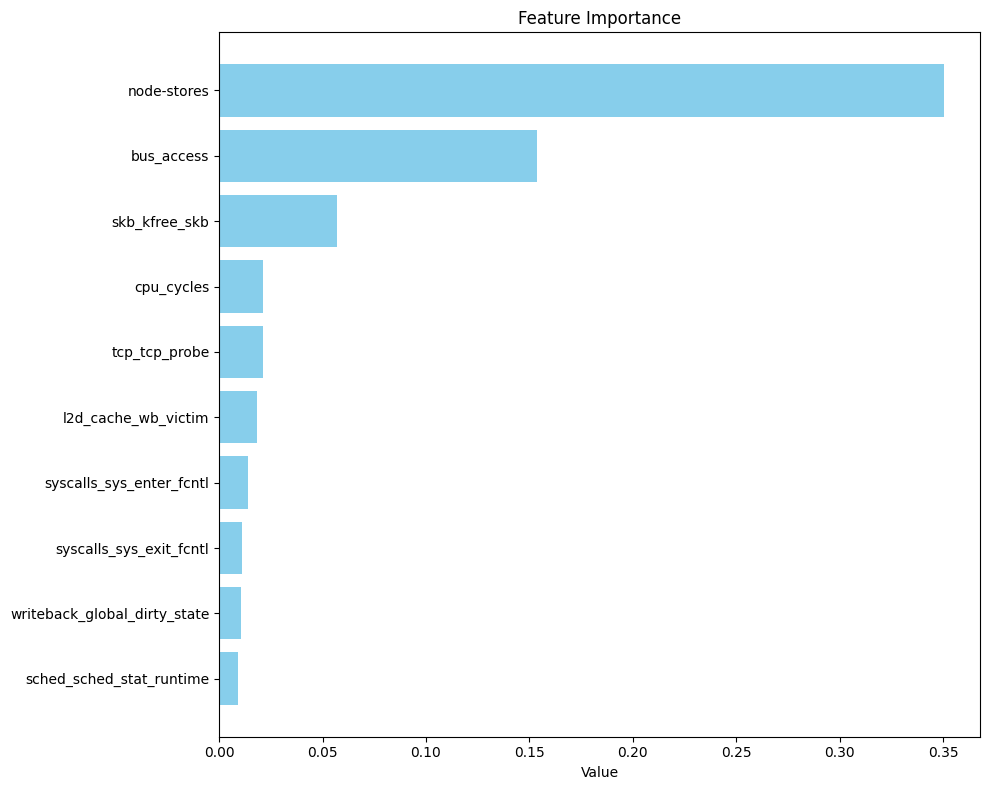

In [5]:
import matplotlib.pyplot as plt

# Assume top_features is a Pandas Series, for example:
# top_features = pd.Series({...})

features = top_features[:10].index
values = top_features[:10].values

plt.figure(figsize=(10, 8))
plt.barh(features, values, color='skyblue')
plt.xlabel('Value')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # To show the largest feature at the top
plt.tight_layout()
#plt.savefig('plots/feature_importance.png')
plt.show()
plt.close()


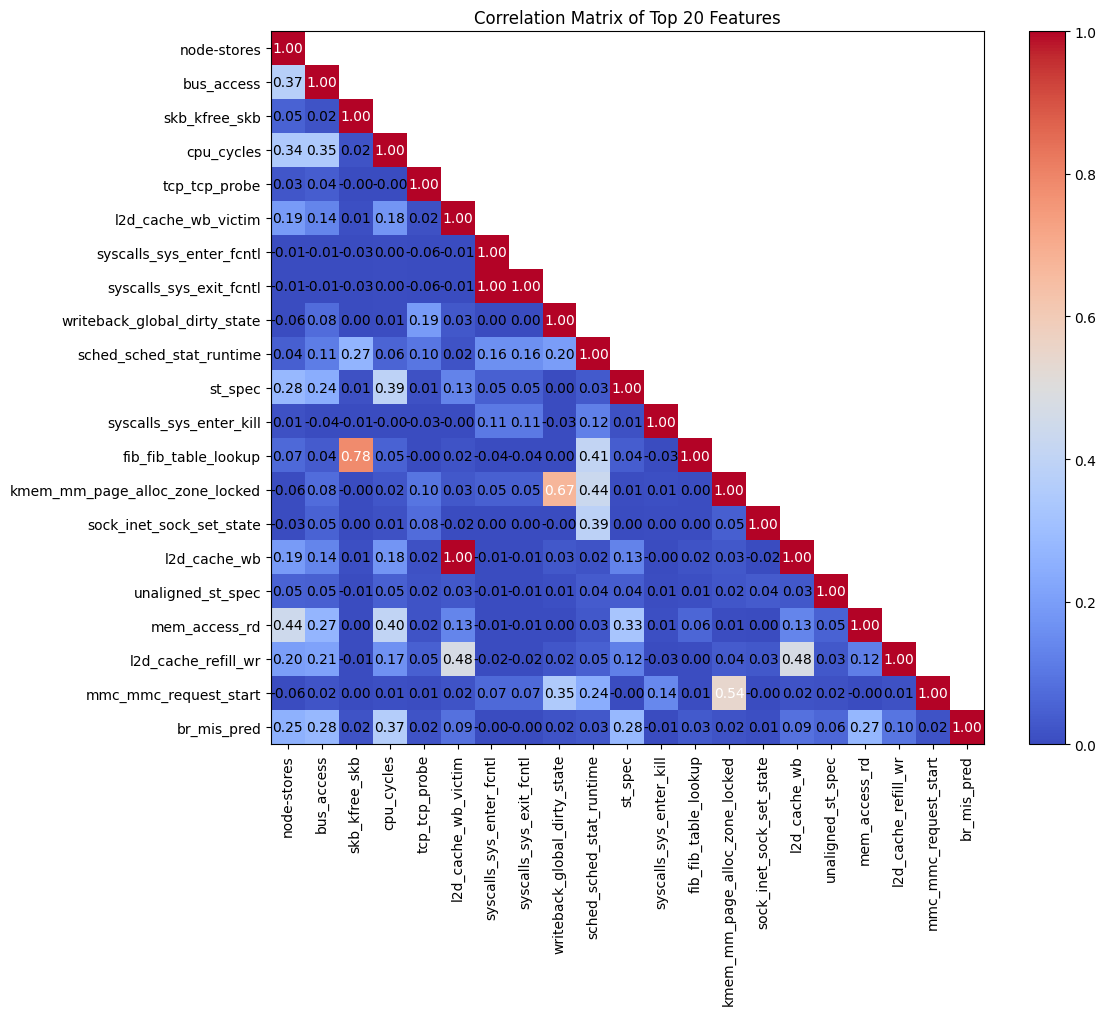

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Verwende die Top 20 Features aus deinem vorherigen Schritt
top20_features = top_features.index

# Erstelle Subset mit den Top 20 Features aus X
X_top20 = X[top20_features]

# Berechne Korrelationsmatrix
corr_matrix = X_top20.corr()

# Erstelle Maske für obere Dreiecksmatrix
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Wende Maske an (setzt obere Dreiecksmatrix auf NaN, damit nur untere sichtbar ist)
corr_matrix_masked = corr_matrix.mask(mask)

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix_masked, cmap='coolwarm', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.title("Correlation Matrix of Top 20 Features")

# Achsenbeschriftung
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Korrelationswerte nur in der unteren Dreiecksmatrix anzeigen
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        if i >= j:
            value = corr_matrix.iloc[i, j]
            color = 'white' if abs(value) > 0.5 else 'black'
            plt.text(j, i, f'{value:.2f}', ha='center', va='center', color=color)

plt.tight_layout()
plt.savefig('feature_plots/corrlationMatrix_DT.png')
plt.show()


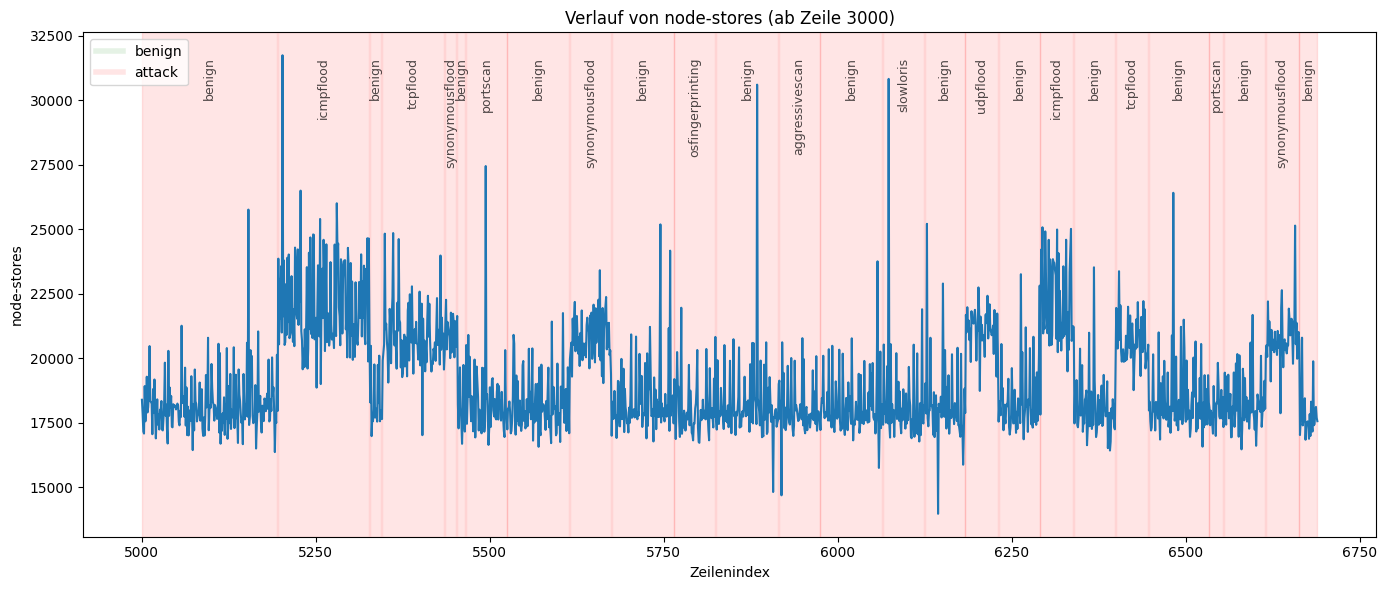

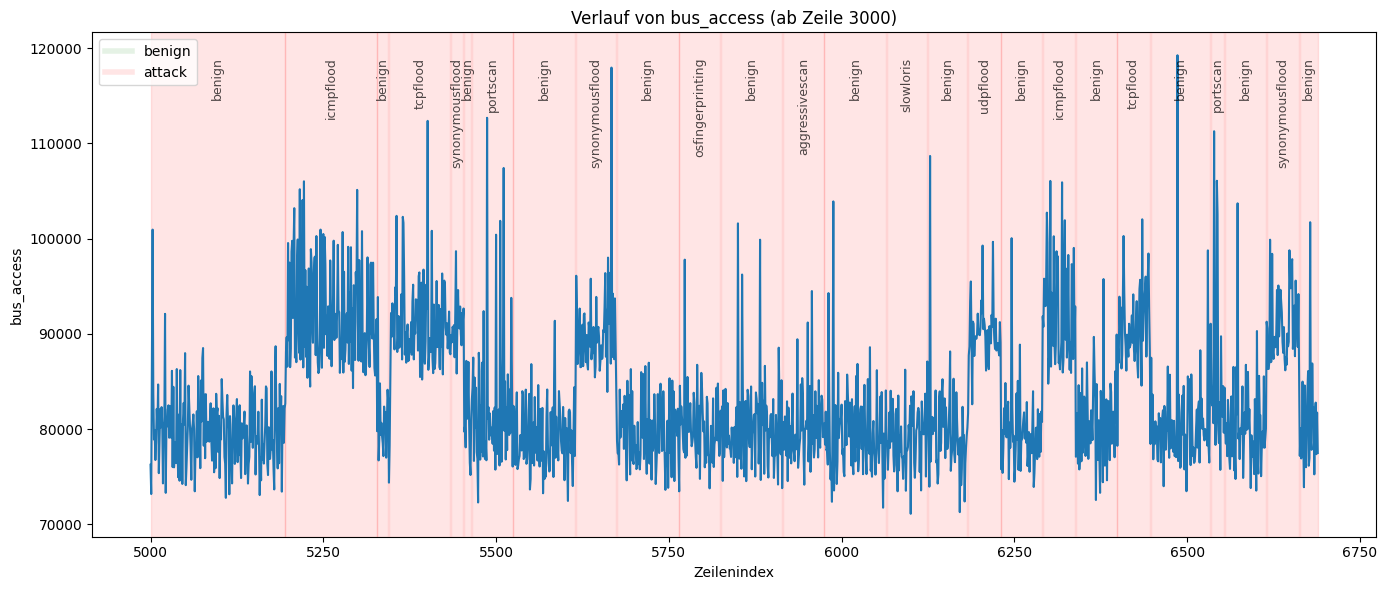

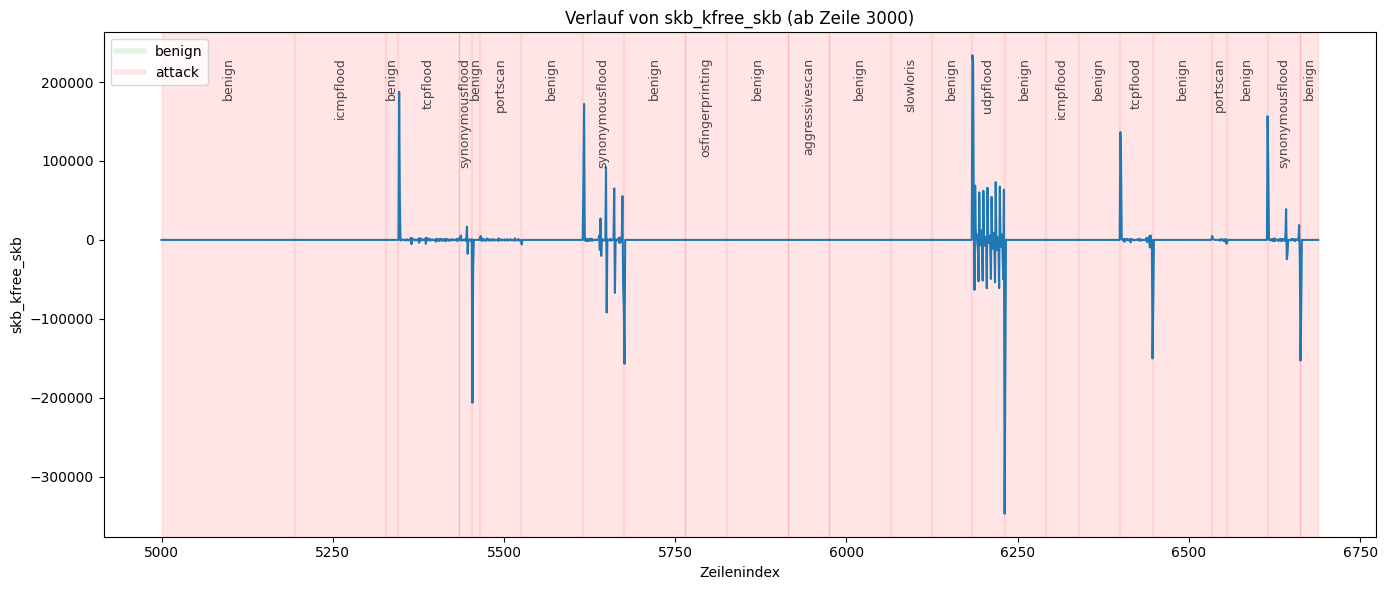

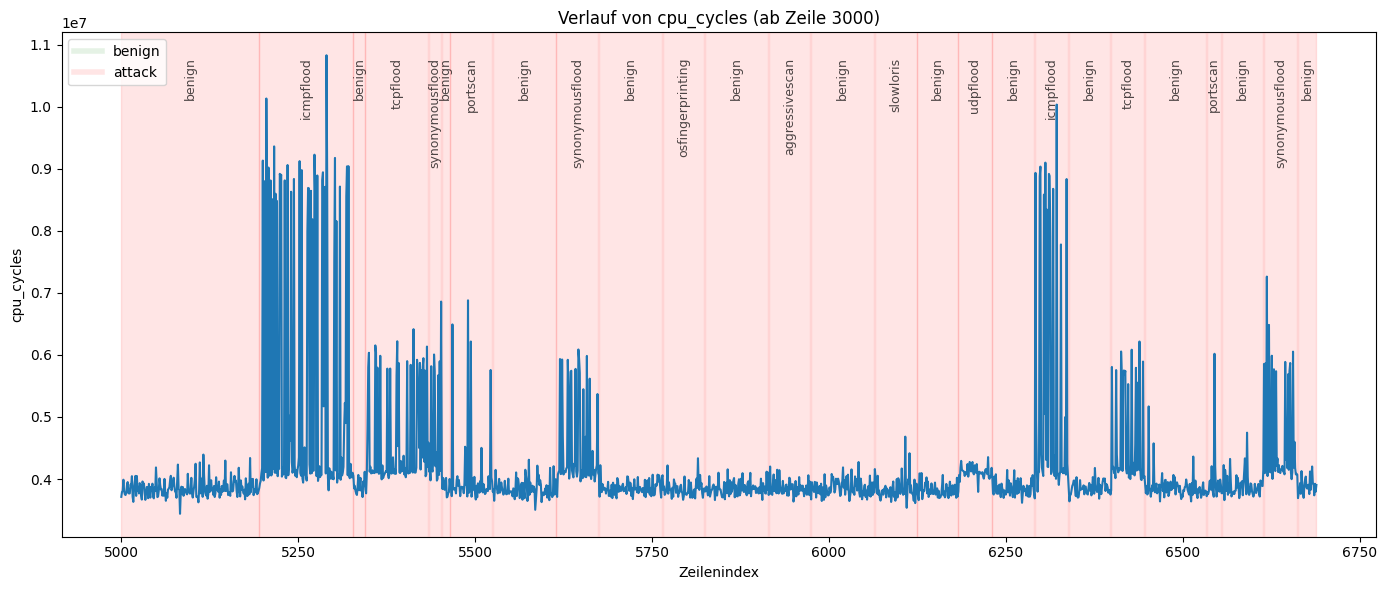

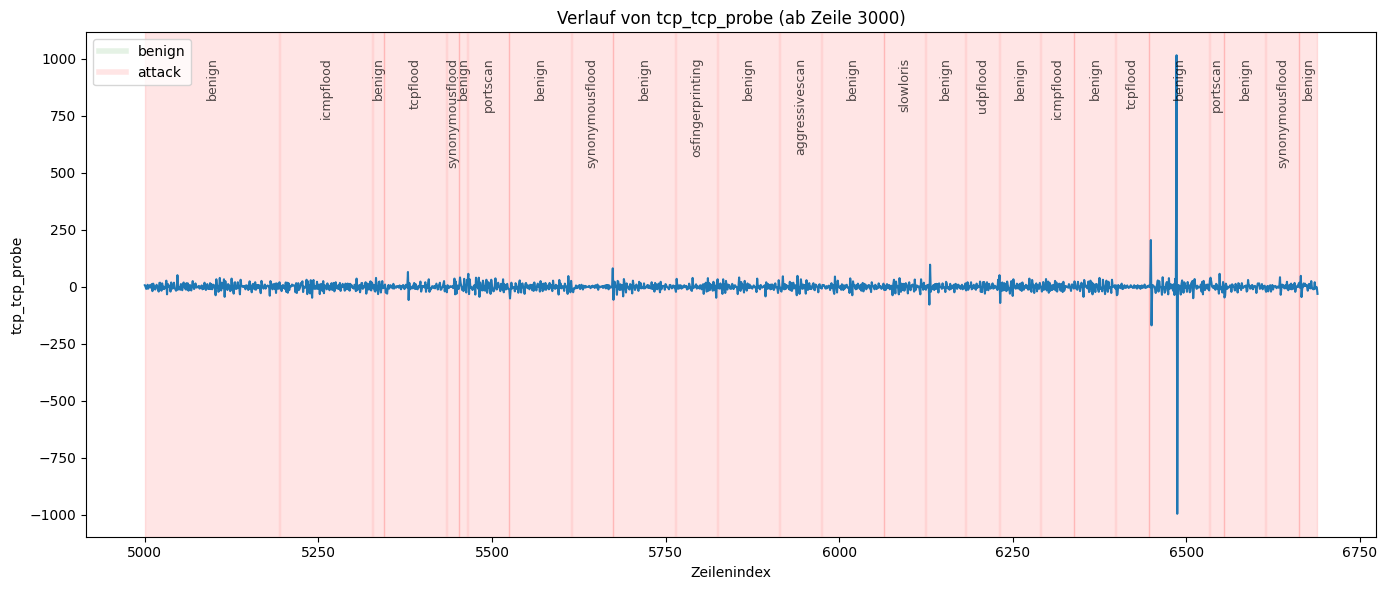

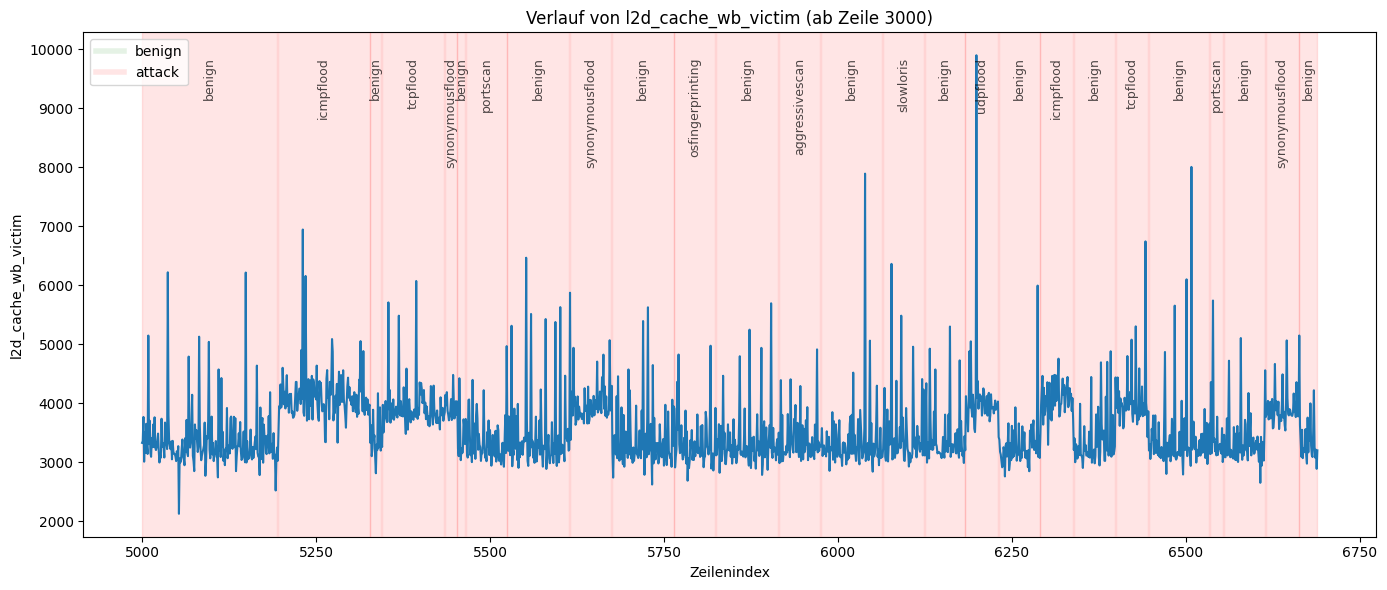

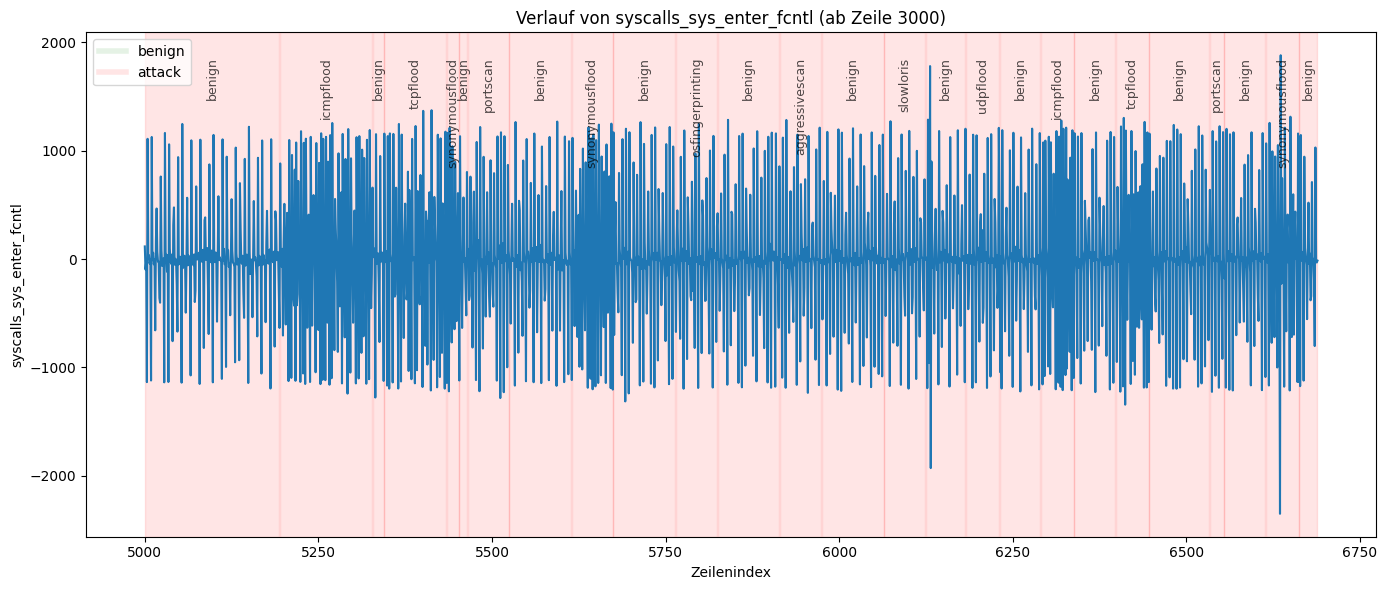

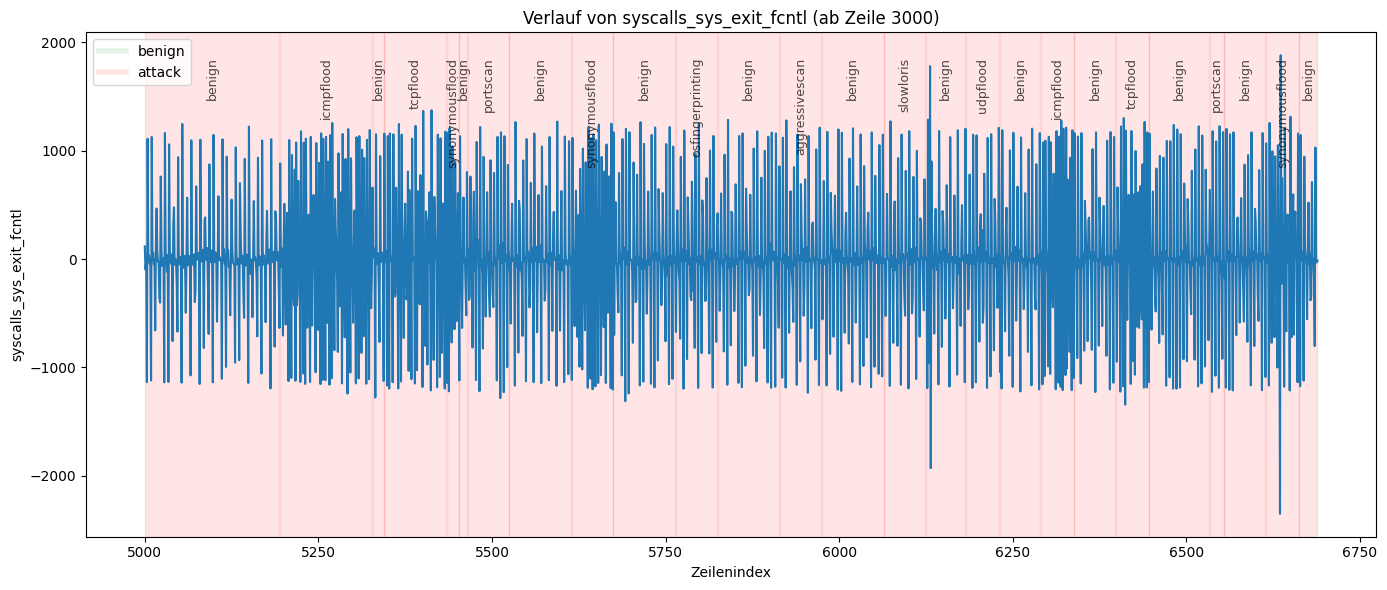

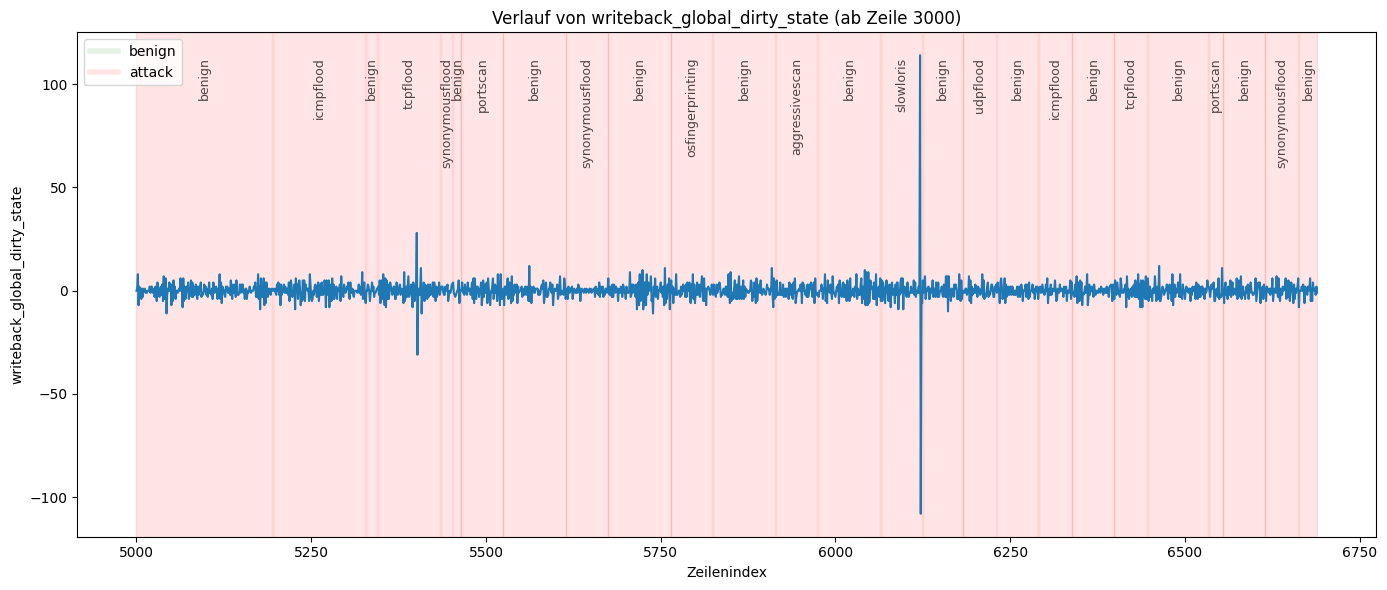

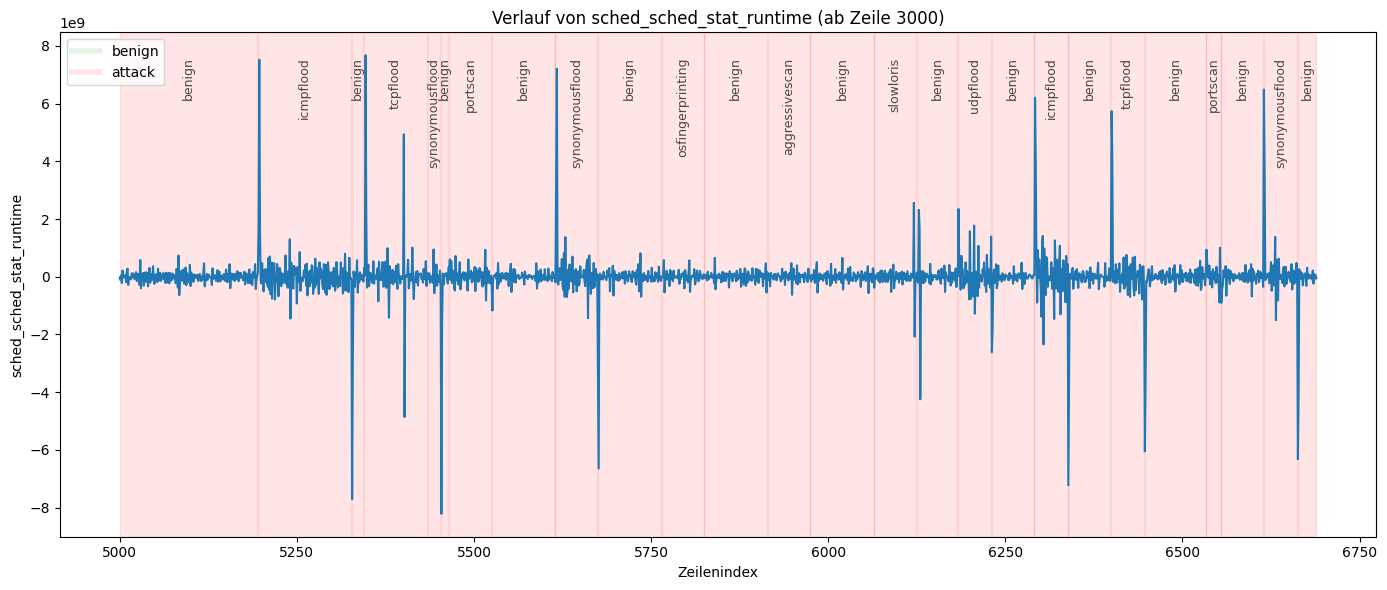

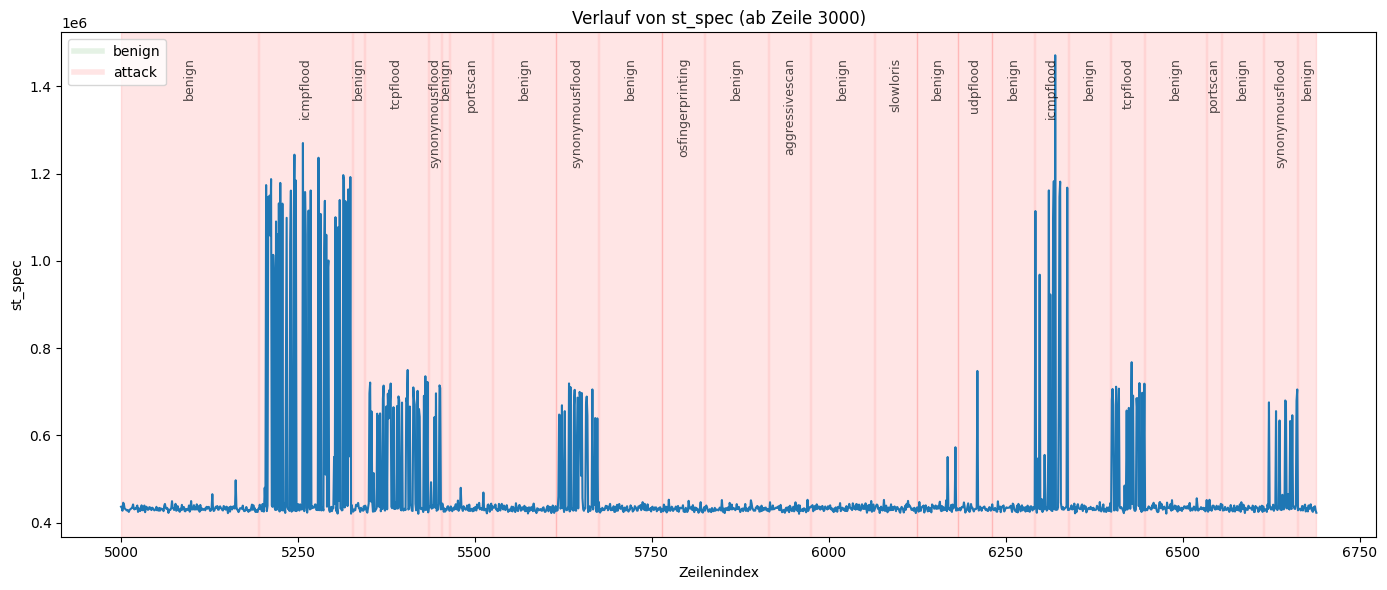

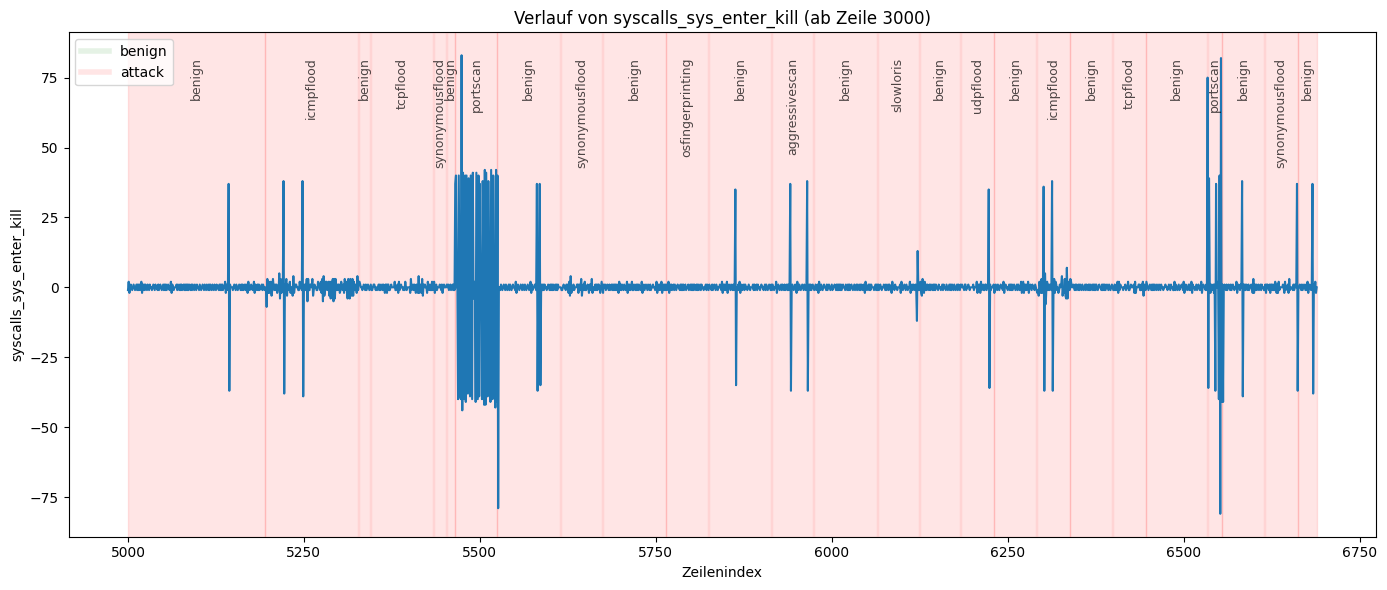

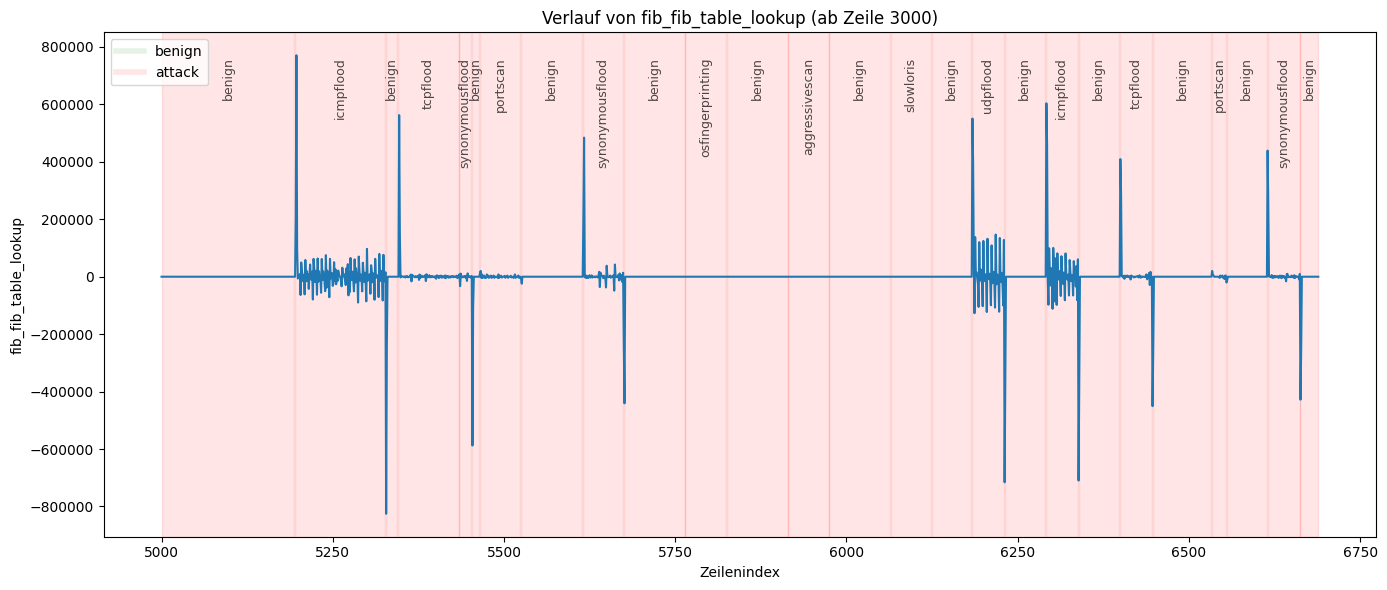

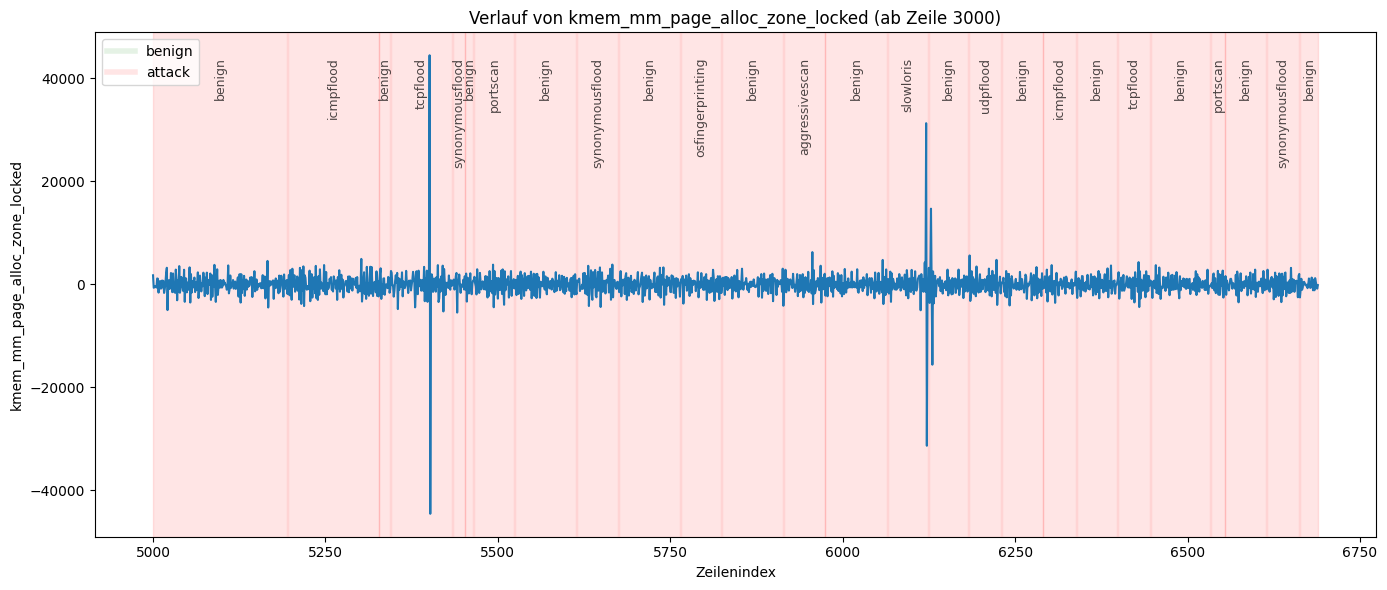

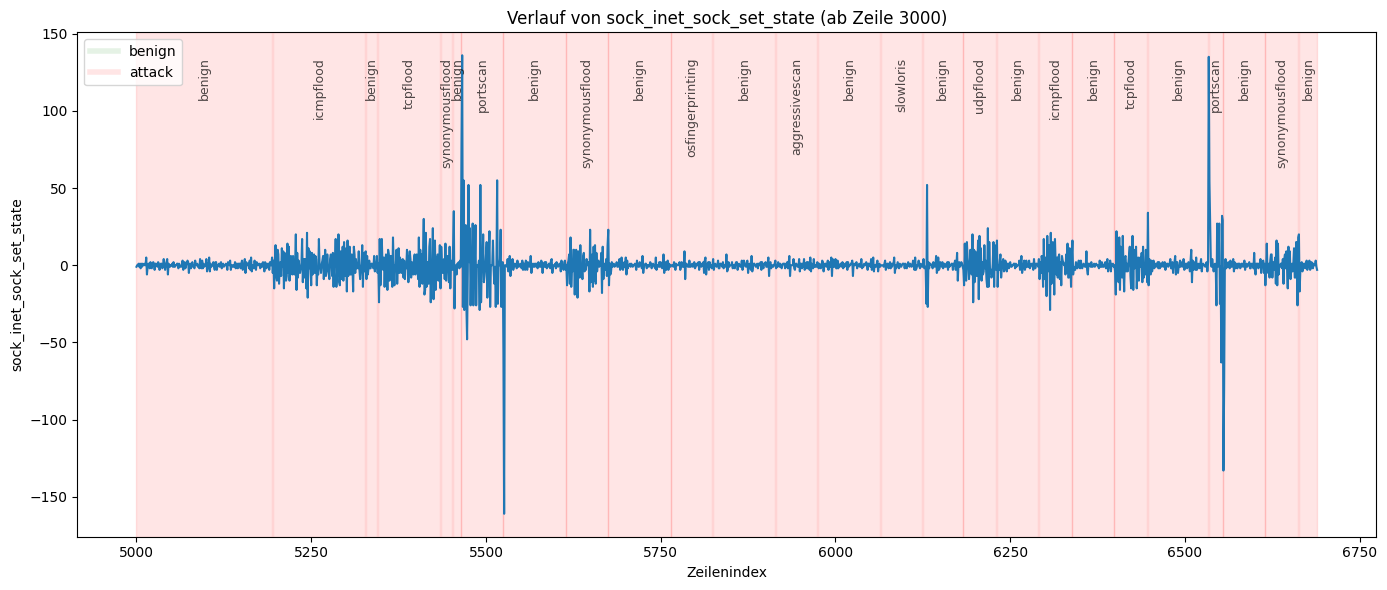

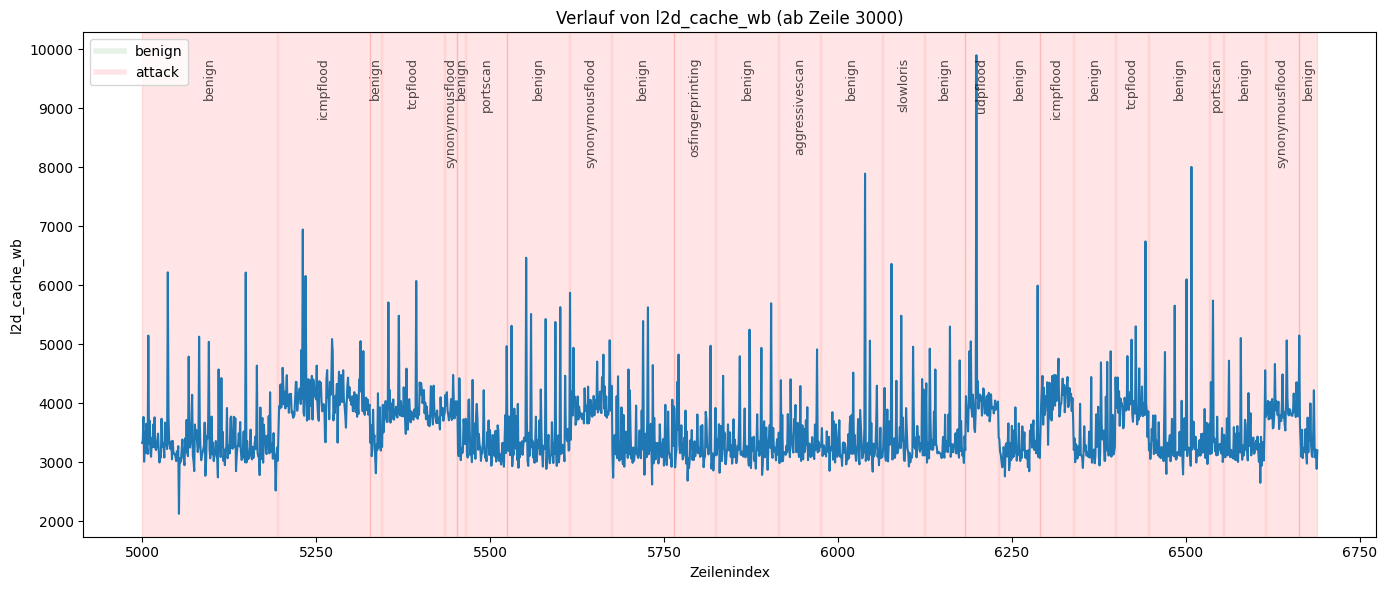

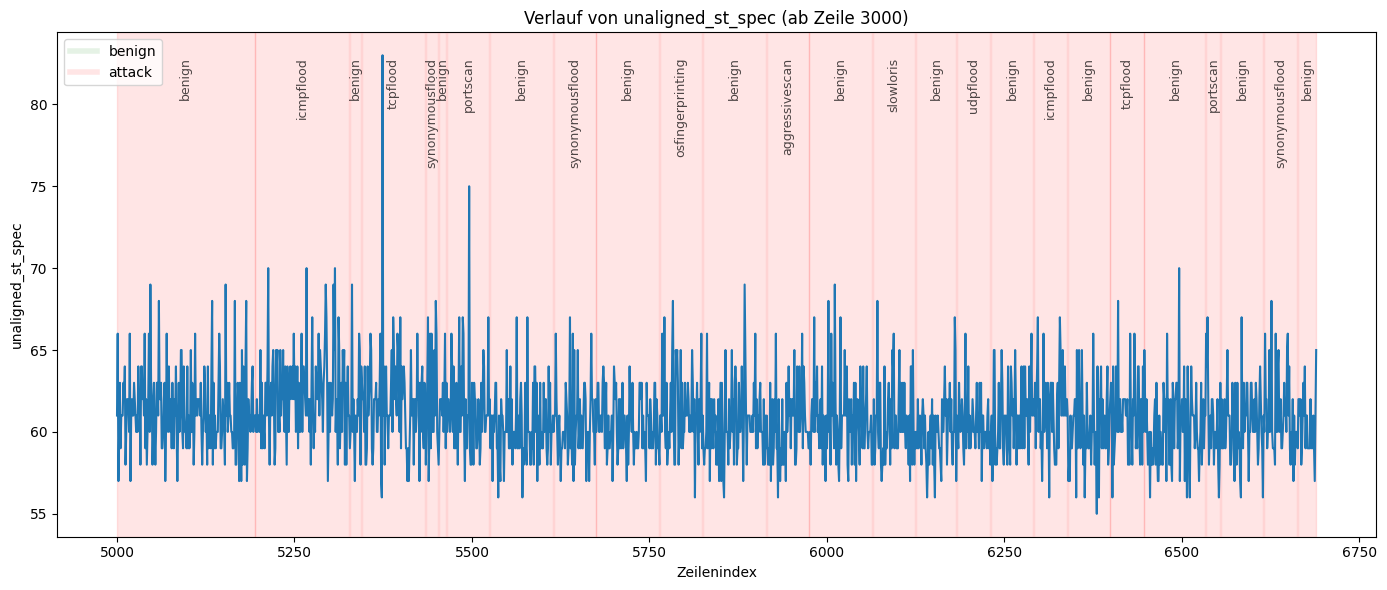

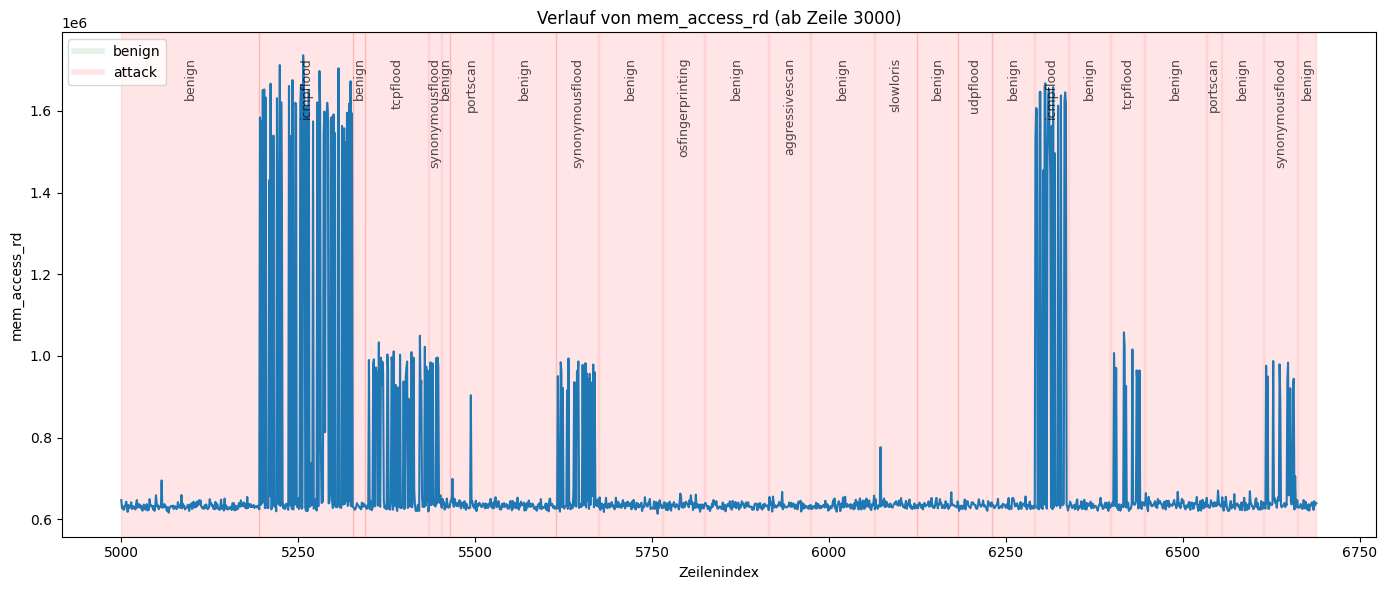

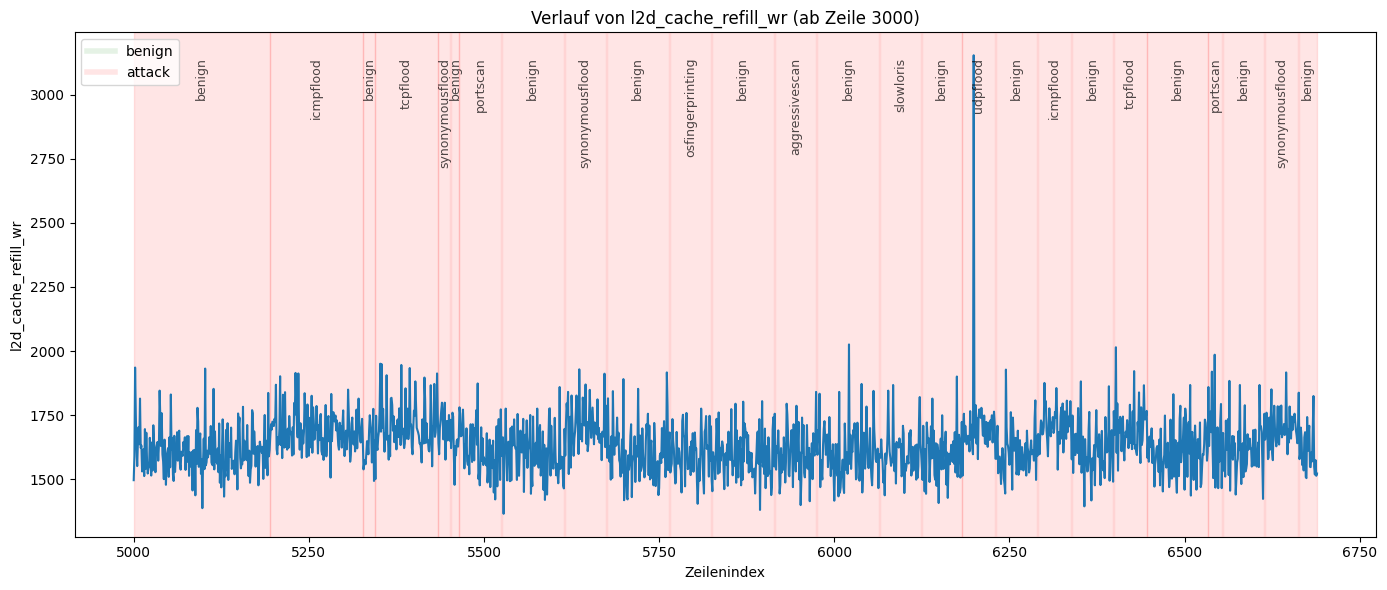

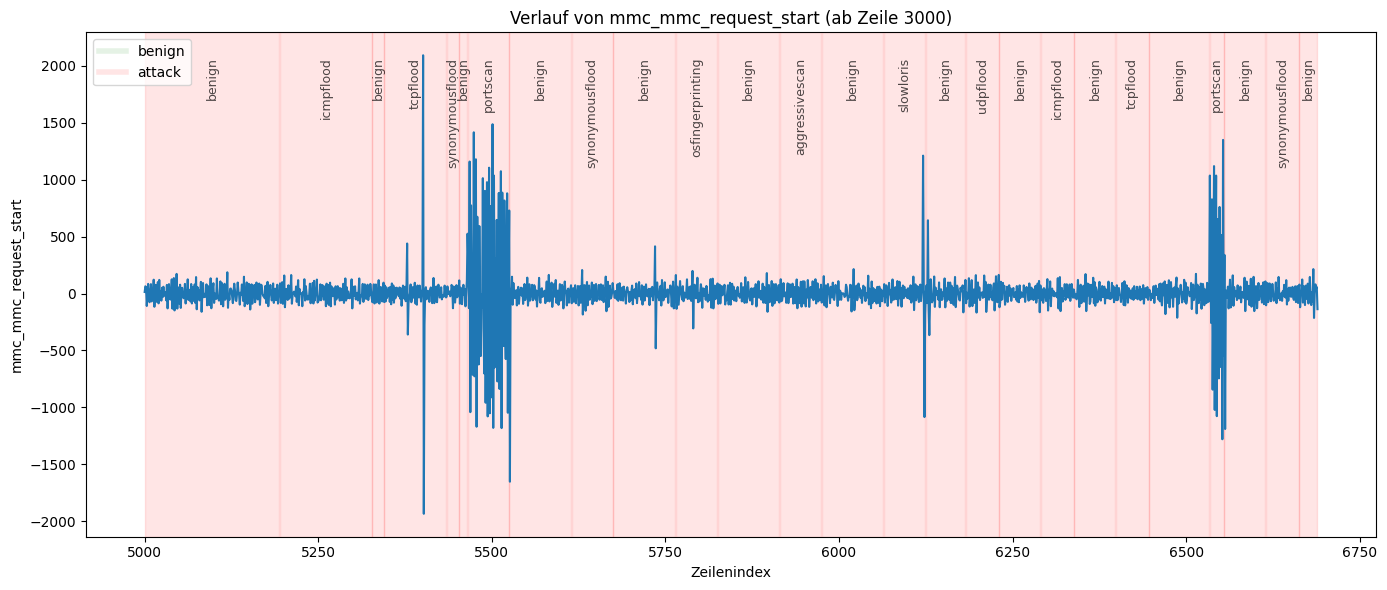

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

df_subset = df.iloc[5000:]
selected_features = top20_features[:20]

for feat in selected_features:
    plt.figure(figsize=(14, 6))
    plt.plot(df_subset.index, df_subset[feat], label=feat)
    
    ymin, ymax = plt.ylim()
    start_idx = 0
    current_label = df_subset['Label'].iloc[0]
    current_attack = df_subset['attack'].iloc[0]

    for i in range(1, len(df_subset)):
        label_changed = df_subset['Label'].iloc[i] != current_label
        attack_changed = df_subset['attack'].iloc[i] != current_attack
        if label_changed or attack_changed:
            color = 'green' if current_label == 'benign' else 'red'
            plt.axvspan(df_subset.index[start_idx], df_subset.index[i-1], color=color, alpha=0.1)
            mid_pos = (df_subset.index[start_idx] + df_subset.index[i-1]) / 2
            plt.text(
                mid_pos,
                ymax - (ymax - ymin) * 0.05,
                current_attack,
                ha='center',
                va='top',
                fontsize=9,
                color='black',
                alpha=0.7,
                rotation=90
            )
            start_idx = i
            current_label = df_subset['Label'].iloc[i]
            current_attack = df_subset['attack'].iloc[i]

    # Letztes Segment einfärben und beschriften
    color = 'green' if current_label == 'benign' else 'red'
    plt.axvspan(df_subset.index[start_idx], df_subset.index[-1], color=color, alpha=0.1)
    mid_pos = (df_subset.index[start_idx] + df_subset.index[-1]) / 2
    plt.text(
        mid_pos,
        ymax - (ymax - ymin) * 0.05,
        current_attack,
        ha='center',
        va='top',
        fontsize=9,
        color='black',
        alpha=0.7,
        rotation=90
    )

    plt.title(f'Verlauf von {feat} (ab Zeile 3000)')
    plt.xlabel('Zeilenindex')
    plt.ylabel(feat)
    handles = [
        plt.Line2D([0], [0], color='green', lw=4, alpha=0.1, label='benign'),
        plt.Line2D([0], [0], color='red', lw=4, alpha=0.1, label='attack')
    ]
    plt.legend(handles=handles)
    plt.tight_layout()
    plt.show()
